# SpiceRack — Model Training Notebook

Built for the original RecipeNLG format: `Unnamed: 0`, `title`, `ingredients`, `directions`, `link`, `source`, `NER`.  
Spices are extracted from the `NER` column at load time using `ALIASES` + `CANONICAL_SPICES`.

**Pipeline:** NER extraction → TF-IDF (locked to canonical vocab) → SVD → seeded K-Means → precomputed matrix → save


## 1 — Imports

In [11]:
import ast, csv, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from collections import Counter
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from scipy.sparse import hstack, csr_matrix

from spice_data_v2 import SPICES, ALIASES, CANONICAL_SPICES, FLAVOR_PROFILES, REGION_PROFILES

print(f"loaded {len(CANONICAL_SPICES)} spices, {len(FLAVOR_PROFILES)} flavor profiles, {len(REGION_PROFILES)} regions")


loaded 179 spices, 15 flavor profiles, 16 regions


## 2 — Configuration

In [16]:
DATASET_PATH           = "cookingdataset/RecipeNLG_dataset.csv"   # swap to full CSV for 2M
MODEL_OUT              = "spicerack_model.joblib"
N_FLAVOR_COMPONENTS    = 50    # SVD latent dimensions (bump to 50-100 for full dataset)
N_MEAL_CLUSTERS        = 4     # title clusters → becomes your meal-type labels
N_FLAVOR_CLUSTERS      = 15     # spice flavor clusters
USE_INGREDIENTS        = True  # blend non-spice ingredient signal
INGREDIENT_WEIGHT      = 0.3   # 0.0 = pure spice signal, 1.0 = pure ingredient signal

PROFILE_NAMES = list(FLAVOR_PROFILES.keys())
print(f"Dataset      : {DATASET_PATH}")
print(f"SVD dims     : {N_FLAVOR_COMPONENTS}")
print(f"Meal clusters: {N_MEAL_CLUSTERS}")
print(f"Flavor clusters: {N_FLAVOR_CLUSTERS}")


Dataset      : cookingdataset/RecipeNLG_dataset.csv
SVD dims     : 50
Meal clusters: 4
Flavor clusters: 15


## 3 — NER extraction helpers

The full RecipeNLG dataset has no `spices` column — spices are buried inside `NER`
alongside every other ingredient (chicken, flour, lemon...).

`canonicalize()` runs each NER token through `ALIASES` first (resolving variants like
`grnd black pepper` → `black pepper`), then checks membership in `CANONICAL_SPICES`.
Tokens that don't resolve are kept as non-spice ingredients for the optional ingredient signal.

A small set of extra aliases patches common NER variants that aren't in `spice_data_v2.py`.


In [12]:
import re

def clean(s) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"[^a-z\s']", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def to_canonical(spice):
    n = clean(spice)
    return clean(ALIASES.get(n, n))

# sorted longest-first so "smoked paprika" beats "paprika"
SPICE_PATTERNS = sorted(
    [(sp, clean(sp), re.compile(rf"(^| ){re.escape(clean(sp))}( |$)")) for sp in SPICES],
    key=lambda x: -len(x[0])
)

def get_spices_from_text(ingredients):
    if isinstance(ingredients, list):
        raw = " ".join(str(x) for x in ingredients)
    else:
        raw = str(ingredients)
    text = clean(raw)
    found = set()
    for _, norm, pat in SPICE_PATTERNS:
        if pat.search(" " + text + " "):
            found.add(norm)
    return {to_canonical(sp) for sp in found}

def parse_ingredient_string(x) -> list[str]:
    if isinstance(x, list):
        return [str(i) for i in x]
    if not isinstance(x, str):
        return []
    s = x.strip()
    if s.startswith("[") and s.endswith("]"):
        items = re.findall(r"'([^']*)'|\"([^\"]*)\"", s)
        parsed = [a if a else b for a, b in items]
        return parsed if parsed else [s]
    return [s]

# Quick sanity check
test_ing = ["1/4 tsp grnd black pepper", "1 clove garlic", "1 tsp vanilla extract", "2 cups chicken broth"]
print("Regex extraction check:")
print(" ", get_spices_from_text(test_ing))

Regex extraction check:
  {'vanilla', 'garlic', 'black pepper'}


## 4 — Load dataset

Reads the original RecipeNLG format (`NER` column only — no pre-computed `spices`).  
Each row's `NER` list is scanned: anything that resolves via `canonicalize()` becomes
the recipe's spice list. Rows with zero canonical spices are skipped.


In [14]:
MEAL_KEYWORDS = {
    "Breakfast": ["pancake","waffle","omelette","muffin","oatmeal","toast","crepe",
                  "frittata","scone","porridge","quiche","bagel"],
    "Lunch":     ["sandwich","salad","soup","wrap","quesadilla","panini","chowder",
                  "bisque","burger","taco","burrito"],
    "Dinner":    ["steak","pasta","roast","stew","casserole","salmon","pork","beef",
                  "shrimp","curry","risotto","chicken","lamb","fillet","braise","ragu"],
    "Dessert":   ["cake","cookie","pie","brownie","pudding","tart","cheesecake",
                  "sweet","dessert","macaron","toffee","fudge","mousse","sorbet"],
}

def detect_meal_type(title: str, ingredients: list) -> str:
    combined = title.lower() + " " + " ".join(ingredients).lower()
    for meal, kws in MEAL_KEYWORDS.items():
        if any(k in combined for k in kws):
            return meal
    return "Dinner"

recipes = []
skipped = 0

with open(DATASET_PATH, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        try:
            row_id      = row.get("Unnamed: 0") or row.get("") or "0"
            ingredients = parse_ingredient_string(row["ingredients"])
            spices      = get_spices_from_text(ingredients)

            if not spices:
                skipped += 1
                continue

            recipes.append({
                "id":          int(row_id),
                "title":       row["title"].strip(),
                "spices":      sorted(spices),
                "ingredients": ingredients,
                "meal_type":   detect_meal_type(row["title"], ingredients),
            })
        except Exception:
            skipped += 1

total = len(recipes) + skipped
print(f"Loaded  : {len(recipes):,}  ({len(recipes)/total*100:.1f}% had canonical spices)")
print(f"Skipped : {skipped:,}  (no spices found)")
print()
for r in recipes[:5]:
    print(f"  {r['title'][:50]:<50}  {r['spices']}")

Loaded  : 1,684,564  (75.5% had canonical spices)
Skipped : 546,578  (no spices found)

  No-Bake Nut Cookies                                 ['vanilla']
  Creamy Corn                                         ['garlic', 'salt']
  Cheeseburger Potato Soup                            ['salt']
  Rhubarb Coffee Cake                                 ['salt', 'vanilla']
  Double Cherry Delight                               ['ginger']


In [15]:
df = pd.DataFrame(recipes)
print(df.shape)
df.columns

(1684564, 5)


Index(['id', 'title', 'spices', 'ingredients', 'meal_type'], dtype='object')

In [17]:
df.head(10)

,id,title,spices,ingredients,meal_type
0,0,No-Bake Nut Cookies,[vanilla],"[1 c. firmly packed brown sugar, 1/2 c. evapor...",Dessert
1,2,Creamy Corn,"[garlic, salt]","[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. c...",Dinner
2,5,Cheeseburger Potato Soup,[salt],"[6 baking potatoes, 1 lb. of extra lean ground...",Lunch
3,6,Rhubarb Coffee Cake,"[salt, vanilla]","[1 1/2 c. sugar, 1/2 c. butter, 1 egg, 1 c. bu...",Dessert
4,10,Double Cherry Delight,[ginger],"[1 (17 oz.) can dark sweet pitted cherries, 1/...",Dessert
5,13,Taco Salad Chip Dip,[taco seasoning],"[8 oz. Ortega taco sauce, 8 oz. sour cream, 8 ...",Lunch
6,15,Fresh Strawberry Pie,[salt],"[1 baked pie shell, 1 qt. cleaned strawberries...",Dessert
7,19,Eggless Milkless Applesauce Cake,"[cinnamon, cloves, nutmeg]","[3/4 c. sugar, 1/2 c. shortening, 1 1/2 c. app...",Dessert
8,20,"Grandma Hanrath'S Banana Breadfort Collins, Co...",[salt],"[1 c. sugar, 1/2 c. shortening, 2 eggs (add on...",Dinner
9,22,Cuddy Farms Marinated Turkey,"[garlic, salt]","[2 c. 7-Up or Sprite, 1 c. vegetable oil, 1 c....",Dinner


## 5 — Explore

Unique canonical spices in dataset : 178 / 179
Vocabulary coverage                : 99.4%
Avg spices per recipe              : 2.6



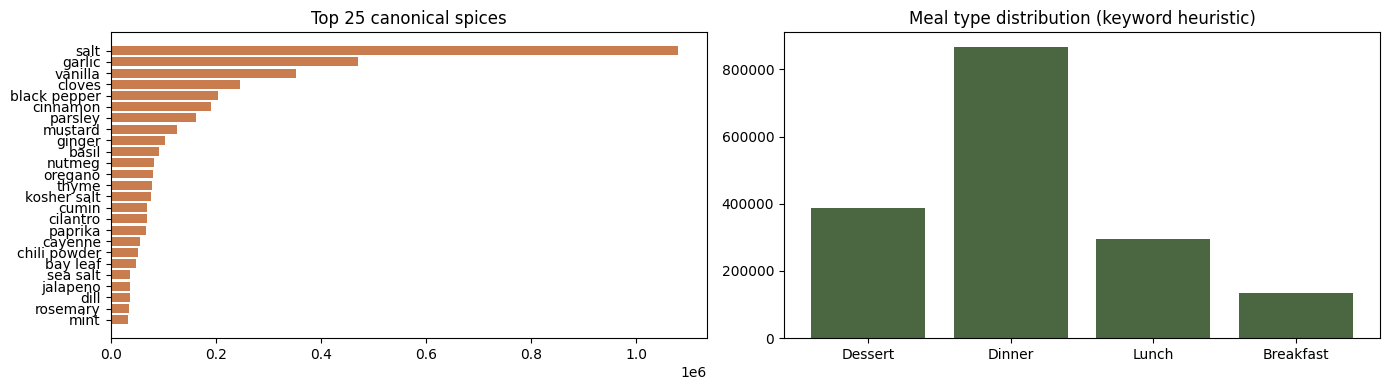

In [18]:
spice_counts = Counter(s for r in recipes for s in r["spices"])
meal_counts  = Counter(r["meal_type"] for r in recipes)

print(f"Unique canonical spices in dataset : {len(spice_counts)} / {len(CANONICAL_SPICES)}")
print(f"Vocabulary coverage                : {len(spice_counts)/len(CANONICAL_SPICES)*100:.1f}%")
print(f"Avg spices per recipe              : {np.mean([len(r['spices']) for r in recipes]):.1f}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
top = spice_counts.most_common(25)
axes[0].barh([s for s,_ in reversed(top)], [c for _,c in reversed(top)], color="#C97D4E")
axes[0].set_title("Top 25 canonical spices")
axes[1].bar(meal_counts.keys(), meal_counts.values(), color="#4A6741")
axes[1].set_title("Meal type distribution (keyword heuristic)")
plt.tight_layout(); plt.show()


## 6 — TF-IDF

Two separate vectorizers, combined with weighted stacking:

- **Spice vectorizer** — vocabulary locked to `CANONICAL_SPICES`. Fixed size regardless
  of what's in the dataset. Ensures user pantry tokens always land in the same columns
  as recipe spice tokens at query time.
- **Ingredient vectorizer** — free vocabulary over non-spice NER tokens (top 500 by frequency).
  Adds context: "chicken" vs "salmon" both have thyme, but they're different recipes.

The final matrix is `[spice_cols × 0.7  |  ingredient_cols × 0.3]` horizontally stacked.


In [19]:
# Spice TF-IDF — locked vocabulary
spice_vocab = [s.replace(" ", "_") for s in CANONICAL_SPICES]
spice_tfidf = TfidfVectorizer(vocabulary=spice_vocab)
spice_docs  = [spice_doc(r["spices"]) for r in recipes]
if not spice_docs:
    raise ValueError(
        "No spice documents available for TF-IDF. "
        "Check that the dataset loaded correctly and that recipes contain canonical spices."
    )
X_spice = spice_tfidf.fit_transform(spice_docs)
print(f"Spice matrix     : {X_spice.shape}  (recipes × {len(CANONICAL_SPICES)} canonical spices)")

# Ingredient TF-IDF — free vocabulary
if USE_INGREDIENTS:
    ing_docs  = [ingredient_doc(r["ingredients"], set(r["spices"])) for r in recipes]
    ing_tfidf = TfidfVectorizer(max_features=500, min_df=2)
    X_ing     = ing_tfidf.fit_transform(ing_docs)
    X = hstack([X_spice * (1 - INGREDIENT_WEIGHT), X_ing * INGREDIENT_WEIGHT])
    print(f"Ingredient matrix: {X_ing.shape}")
    print(f"Combined matrix  : {X.shape}")
else:
    X         = X_spice
    ing_tfidf = None
    print("Ingredient signal disabled")

print()
idf_map = dict(zip(spice_tfidf.get_feature_names_out(), spice_tfidf.idf_))
print("Most distinctive (high IDF):")
for sp, sc in sorted(idf_map.items(), key=lambda x: -x[1])[:8]:
    print(f"  {sp.replace('_',' '):<28}  {sc:.3f}")
print("Least distinctive (low IDF):")
for sp, sc in sorted(idf_map.items(), key=lambda x: x[1])[:8]:
    print(f"  {sp.replace('_',' '):<28}  {sc:.3f}")


Spice matrix     : (1684564, 179)  (recipes × 179 canonical spices)
Ingredient matrix: (1684564, 500)
Combined matrix  : (1684564, 679)

Most distinctive (high IDF):
  piment d'espelette            15.337
  scotch bonnet powder          15.337
  za'atar                       15.337
  dried pomegranate seed        14.644
  kombu powder                  14.644
  liquid smoke powder           14.644
  mulato chili powder           14.644
  shiitake powder               14.644
Least distinctive (low IDF):
  salt                          1.445
  garlic                        2.274
  vanilla                       2.565
  cloves                        2.923
  black pepper                  3.108
  cinnamon                      3.180
  parsley                       3.338
  mustard                       3.585


## 7 — Title clustering (learned meal categories)

K-Means on recipe titles discovers meal-type groups without hardcoded keyword lists.  
After running, inspect the printed top words per cluster and update `MEAL_CLUSTER_LABELS` to match.


In [20]:
titles = [r["title"] for r in recipes]

title_tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, stop_words="english")
T = title_tfidf.fit_transform(titles)

title_svd = TruncatedSVD(n_components=min(20, T.shape[1]-1, T.shape[0]-1), random_state=42)
T_reduced = title_svd.fit_transform(T)

title_km = KMeans(n_clusters=N_MEAL_CLUSTERS, random_state=42, n_init=10)
title_labels = title_km.fit_predict(T_reduced)

for r, label in zip(recipes, title_labels):
    r["meal_cluster"] = int(label)

title_feats = title_tfidf.get_feature_names_out()
centroids_title = title_km.cluster_centers_ @ title_svd.components_

print("Top words per title cluster — use these to set MEAL_CLUSTER_LABELS below:")
print()
for cid in range(N_MEAL_CLUSTERS):
    top_words = [title_feats[i] for i in centroids_title[cid].argsort()[-10:][::-1]]
    samples   = [r["title"] for r in recipes if r["meal_cluster"] == cid][:3]
    print(f"  Cluster {cid}: {', '.join(top_words)}")
    print(f"  Examples : {', '.join(samples)}")
    print()


Top words per title cluster — use these to set MEAL_CLUSTER_LABELS below:

  Cluster 0: salad, bread, sauce, cookies, soup, cheese, casserole, potato, baked, rice
  Examples : No-Bake Nut Cookies, Creamy Corn, Cheeseburger Potato Soup

  Cluster 1: chicken, chicken salad, salad, chicken casserole, rice, casserole, fried, chicken rice, soup, fried chicken
  Examples : Summer Chicken, Chicken Stew, Chicken Divan

  Cluster 2: cake, pound cake, pound, chocolate, apple cake, apple, carrot cake, carrot, chocolate cake, coffee
  Examples : Rhubarb Coffee Cake, Eggless Milkless Applesauce Cake, Quick Coffee Cake(6 Servings)

  Cluster 3: pie, pecan, pecan pie, pumpkin, apple, pumpkin pie, apple pie, chocolate, cream, crust
  Examples : Fresh Strawberry Pie, Potato And Cheese Pie, Dream Pie



In [21]:
# ── EDIT based on what you see above ─────────────────────────────────────
MEAL_CLUSTER_LABELS = {
    0: "Dinner",
    1: "Dessert",
    2: "Breakfast",
    3: "Lunch",
}
# ──────────────────────────────────────────────────────────────────────────

for r in recipes:
    r["meal_type_learned"] = MEAL_CLUSTER_LABELS.get(r["meal_cluster"], f"Cluster {r['meal_cluster']}")

print("Meal type distribution (learned):")
for meal, count in Counter(r["meal_type_learned"] for r in recipes).most_common():
    bar = "█" * (count * 30 // len(recipes))
    print(f"  {meal:<12} {count:4d}  {bar}")


Meal type distribution (learned):
  Dinner       1394470  ████████████████████████
  Dessert      130934  ██
  Breakfast    92905  █
  Lunch        66255  █


## 8 — SVD: latent flavor dimensions

`fit_transform` on the combined spice+ingredient matrix is the training step.  
L2-normalization immediately after means cosine similarity = dot product at query time.


SVD components     : 50
Recipe matrix      : (1684564, 50)
Variance explained : 81.0%
Matrix RAM (sample): 673.8 MB
Matrix RAM (2M)    : 400 MB


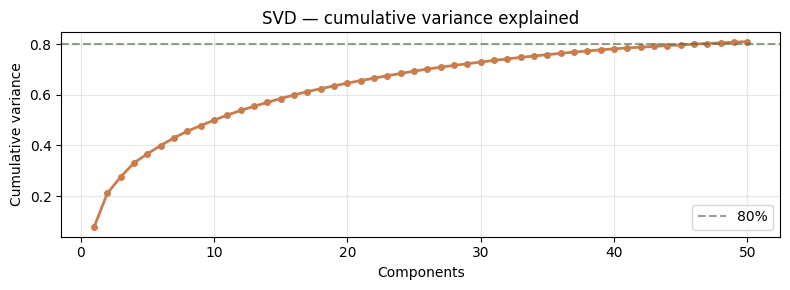

In [22]:
n = min(N_FLAVOR_COMPONENTS, X.shape[1]-1, X.shape[0]-1)

svd = TruncatedSVD(n_components=n, random_state=42)
recipe_vecs = svd.fit_transform(X)
recipe_vecs = normalize(recipe_vecs, norm="l2")

variance = svd.explained_variance_ratio_.sum()
print(f"SVD components     : {n}")
print(f"Recipe matrix      : {recipe_vecs.shape}")
print(f"Variance explained : {variance:.1%}")
print(f"Matrix RAM (sample): {recipe_vecs.nbytes/1e6:.1f} MB")
print(f"Matrix RAM (2M)    : {2_000_000 * n * 4 / 1e6:.0f} MB")

cumvar = np.cumsum(svd.explained_variance_ratio_)
plt.figure(figsize=(8,3))
plt.plot(range(1, n+1), cumvar, marker="o", color="#C97D4E", linewidth=2, markersize=4)
plt.axhline(0.8, color="#4A6741", linestyle="--", alpha=0.6, label="80%")
plt.xlabel("Components"); plt.ylabel("Cumulative variance")
plt.title("SVD — cumulative variance explained")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 9 — Seeded flavor clustering

Each `FLAVOR_PROFILE` from `spice_data_v2.py` is treated as a synthetic recipe
containing all its spices. Projected through TF-IDF → SVD, it becomes a starting
centroid in the same latent space as real recipes.

`n_init=1` because we're supplying expert-defined starting points — random restarts
would discard that knowledge.


In [ ]:
# Build seed centroids from FLAVOR_PROFILES
seed_centroids = []
for pname, spice_set in FLAVOR_PROFILES.items():
    doc   = spice_doc([s for s in spice_set if canonicalize(s)])
    X_sp  = spice_tfidf.transform([doc])
    if USE_INGREDIENTS:
        empty = csr_matrix((1, X_ing.shape[1]))
        X_seed = hstack([X_sp * (1-INGREDIENT_WEIGHT), empty * INGREDIENT_WEIGHT])
    else:
        X_seed = X_sp
    vec = svd.transform(X_seed)[0]
    norm = np.linalg.norm(vec)
    seed_centroids.append(vec / norm if norm > 0 else vec)

seed_centroids = np.array(seed_centroids)
print(f"Seed centroids: {seed_centroids.shape}  ({N_FLAVOR_CLUSTERS} clusters requested)")
print()

# KMeans with seeded init — use only N_FLAVOR_CLUSTERS of the 15 profile seeds
# (takes the first N_FLAVOR_CLUSTERS; edit the slice if you want different ones)
kmeans = KMeans(
    n_clusters=N_FLAVOR_CLUSTERS,
    init=seed_centroids[:N_FLAVOR_CLUSTERS],
    n_init=1,
    max_iter=300,
    random_state=42
)
flavor_labels = kmeans.fit_predict(recipe_vecs)

for r, label in zip(recipes, flavor_labels):
    r["flavor_cluster"] = int(label)
    r["flavor_profile"] = PROFILE_NAMES[label]

sil = silhouette_score(recipe_vecs, flavor_labels)
print(f"Silhouette score: {sil:.3f}  (>0.2 is reasonable)")
print()
print(f"{'ID':<4} {'Profile':<40} {'Recipes':>8}")
print("-"*55)
for i in range(N_FLAVOR_CLUSTERS):
    n_mem = sum(1 for l in flavor_labels if l == i)
    print(f"  {i:<3}  {PROFILE_NAMES[i]:<40} {n_mem:>6}")


Seed centroids: (15, 50)  (15 clusters requested)



In [ ]:
# Inspect: sample recipes per cluster
for i in range(N_FLAVOR_CLUSTERS):
    members = [r for r in recipes if r["flavor_cluster"] == i]
    if not members: continue
    print(f"[{i}] {PROFILE_NAMES[i]}  ({len(members)} recipes)")
    for r in members[:3]:
        print(f"     {r['title'][:55]:<55}  {r['spices']}")
    print()


[0] Smoky & Savory  (190 recipes)
     Marinated Flank Steak Recipe                             ['sesame seed', 'black pepper', 'garlic']
     Tau Kua He Ci Medan'S Favourite Food                     ['garlic']
     Barbecue Sauce                                           ['garlic', 'salt']

[1] Bold & Spicy  (29 recipes)
     Mustard Plus Glazed Pork Chops                           ['crushed red pepper', 'black pepper']
     Hoisin-Glazed Cornish Hen                                ['crushed red pepper']
     Linguine with Sicilian Clam Sauce                        ['salt', 'garlic', 'crushed red pepper', 'basil', 'salt']

[2] Warm & Sweet  (94 recipes)
     Cranberry And Candied Orange Chutney                     ['allspice']
     Pull-Apart Rolls                                         ['cinnamon']
     Creamy Date & Honey Spread                               ['cinnamon']

[3] Herby & Mediterranean  (60 recipes)
     French Chicken Stew                                      ['rosemary

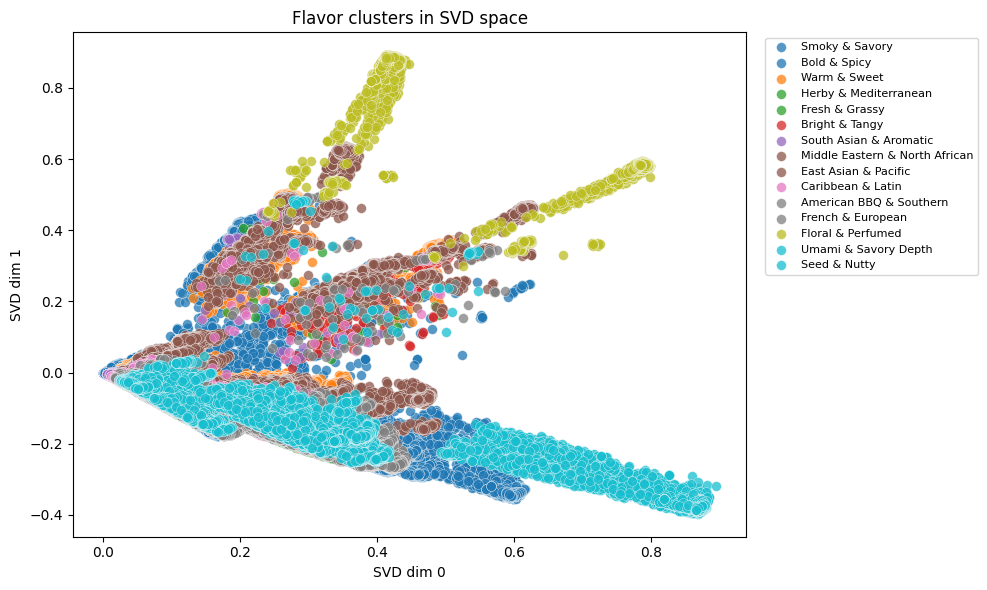

In [ ]:
# Scatter: first 2 SVD dims coloured by cluster
colors = cm.tab10(np.linspace(0, 1, N_FLAVOR_CLUSTERS))
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(N_FLAVOR_CLUSTERS):
    idx = [j for j,r in enumerate(recipes) if r["flavor_cluster"] == i]
    if not idx: continue
    pts = recipe_vecs[idx]
    ax.scatter(pts[:,0], pts[:,1], color=colors[i],
               label=PROFILE_NAMES[i], alpha=0.75, s=50,
               edgecolors="white", linewidth=0.3)
ax.set_title("Flavor clusters in SVD space")
ax.set_xlabel("SVD dim 0"); ax.set_ylabel("SVD dim 1")
ax.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()


## 10 — Precomputed matrix

Because vectors are L2-normalized, `cosine_similarity(u, v) = u · v`.  
Scoring all recipes becomes one matrix multiply: `scores = recipe_matrix @ user_vec`.


In [ ]:
import time

# Build a test user vector
test_pantry = ["garlic", "black pepper", "thyme", "salt"]
doc   = spice_doc(test_pantry)
X_sp  = spice_tfidf.transform([doc])
if USE_INGREDIENTS:
    empty = csr_matrix((1, X_ing.shape[1]))
    X_u   = hstack([X_sp*(1-INGREDIENT_WEIGHT), empty*INGREDIENT_WEIGHT])
else:
    X_u = X_sp
u = svd.transform(X_u)[0]
u /= (np.linalg.norm(u) + 1e-10)

# Loop vs matrix
t0 = time.perf_counter()
_ = [float(cosine_similarity(u.reshape(1,-1), recipe_vecs[i].reshape(1,-1))[0][0])
     for i in range(len(recipes))]
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
scores = recipe_vecs @ u
t_mat  = time.perf_counter() - t0

print(f"Loop   : {t_loop*1000:.1f} ms  ({len(recipes)} recipes)")
print(f"Matrix : {t_mat*1000:.3f} ms  ({len(recipes)} recipes)")
print(f"Speedup: {t_loop/t_mat:.0f}x")
print()
est_2m = t_mat / len(recipes) * 2_000_000 * 1000
print(f"Extrapolated at 2M recipes: {est_2m:.0f} ms  (~{est_2m/1000:.1f}s full matrix)")
print(f"With cluster scoping (~1/6): ~{est_2m/N_FLAVOR_CLUSTERS:.0f} ms")


Loop   : 89.7 ms  (731 recipes)
Matrix : 0.065 ms  (731 recipes)
Speedup: 1383x

Extrapolated at 2M recipes: 177 ms  (~0.2s full matrix)
With cluster scoping (~1/6): ~30 ms


## 11 — Sanity check

In [ ]:
def recommend(pantry, top_n=8):
    doc  = spice_doc(pantry)
    X_sp = spice_tfidf.transform([doc])
    if USE_INGREDIENTS:
        empty = csr_matrix((1, X_ing.shape[1]))
        X_u   = hstack([X_sp*(1-INGREDIENT_WEIGHT), empty*INGREDIENT_WEIGHT])
    else:
        X_u = X_sp
    u = svd.transform(X_u)[0]
    u /= (np.linalg.norm(u) + 1e-10)

    scores  = recipe_vecs @ u
    nearest = int(np.argmin(kmeans.transform(u.reshape(1,-1))[0]))
    mask    = np.array([r["flavor_cluster"] == nearest for r in recipes])
    scores *= mask

    ranked = sorted(zip(scores, recipes), key=lambda x: -x[0])
    out = []
    for sc, r in ranked:
        if sc <= 0: break
        out.append({
            "score":   round(float(sc), 3),
            "title":   r["title"],
            "profile": r["flavor_profile"],
            "matched": [s for s in r["spices"] if s in pantry],
            "missing": [s for s in r["spices"] if s not in pantry],
        })
        if len(out) == top_n: break
    return out

for pantry in [
    ["garlic", "black pepper", "thyme", "salt"],
    ["cinnamon", "vanilla", "nutmeg", "cloves"],
    ["cumin", "coriander", "turmeric", "garam masala"],
]:
    print(f"Pantry: {pantry}")
    for r in recommend(pantry):
        print(f"  {r['score']:.3f}  [{r['profile']:<30}]  {r['title'][:45]}  matched={r['matched']}")
    print()


Pantry: ['garlic', 'black pepper', 'thyme', 'salt']
  1.000  [Smoky & Savory                ]  Southern Italian Ratatouille  matched=['salt', 'black pepper', 'garlic', 'thyme']
  1.000  [Smoky & Savory                ]  Chicken Barley Soup  matched=['garlic', 'salt', 'thyme', 'black pepper']
  1.000  [Smoky & Savory                ]  Lemon Grilled Chicken  matched=['salt', 'black pepper', 'thyme', 'garlic']
  1.000  [Smoky & Savory                ]  Italian Corn Crusted Baked Fish  matched=['garlic', 'thyme', 'salt', 'black pepper']
  0.980  [Smoky & Savory                ]  Savory Rubbed Roast Chicken  matched=['salt', 'thyme', 'garlic', 'black pepper']
  0.961  [Smoky & Savory                ]  Spinach Balls  matched=['garlic', 'thyme', 'black pepper']
  0.960  [Smoky & Savory                ]  Spicy Garlicky Mussels  matched=['garlic', 'thyme', 'black pepper']
  0.855  [Smoky & Savory                ]  Herb Fryer Chicken  matched=['garlic', 'thyme', 'salt', 'black pepper']

Pantry: 

## 12 — Save

In [ ]:
model = {
    "spice_tfidf":      spice_tfidf,
    "ing_tfidf":        ing_tfidf,
    "svd":              svd,
    "use_ingredients":  USE_INGREDIENTS,
    "ingredient_weight": INGREDIENT_WEIGHT,
    "recipe_matrix":    recipe_vecs,
    "kmeans":           kmeans,
    "profile_names":    PROFILE_NAMES[:N_FLAVOR_CLUSTERS],
    "n_clusters":       N_FLAVOR_CLUSTERS,
    "title_tfidf":      title_tfidf,
    "title_svd":        title_svd,
    "title_kmeans":     title_km,
    "meal_cluster_labels": MEAL_CLUSTER_LABELS,
    "recipe_ids":    [r["id"]    for r in recipes],
    "recipe_meta":   {r["id"]: {
        "title":          r["title"],
        "spices":         r["spices"],
        "meal_type":      r["meal_type_learned"],
        "flavor_cluster": r["flavor_cluster"],
        "flavor_profile": r["flavor_profile"],
    } for r in recipes},
    "canonical_spices": CANONICAL_SPICES,
    "aliases":          {**ALIASES, **EXTRA_ALIASES},
    "flavor_profiles":  {k: list(v) for k, v in FLAVOR_PROFILES.items()},
    "region_profiles":  REGION_PROFILES,
    "n_recipes":  len(recipes),
    "variance":   round(float(variance), 4),
    "silhouette": round(float(sil), 4),
}

joblib.dump(model, MODEL_OUT, compress=3)
size_mb = Path(MODEL_OUT).stat().st_size / 1e6
print(f"Saved  : {MODEL_OUT}  ({size_mb:.2f} MB)")
print(f"Recipes: {model['n_recipes']:,}")
print(f"Dims   : {recipe_vecs.shape[1]}")
print(f"Variance: {model['variance']:.1%}   Silhouette: {model['silhouette']:.3f}")
print()
print("Next: copy", MODEL_OUT, "→ SpiceRack-website-main/")


Saved  : spicerack_model.joblib  (0.27 MB)
Recipes: 731
Dims   : 15
Variance: 59.5%   Silhouette: 0.253

Next: copy spicerack_model.joblib → SpiceRack-website-main/


## 13 — Verify reload

In [ ]:
m = joblib.load(MODEL_OUT)
print("Keys    :", list(m.keys()))
print("Recipes :", m["n_recipes"])
print("Matrix  :", m["recipe_matrix"].shape)
print("Clusters:", m["n_clusters"], "→", m["profile_names"])
print()

# Re-run query through loaded model to confirm round-trip
aliases_m = m["aliases"]
canon_m   = m["canonical_spices"]

def canon_loaded(s):
    c = aliases_m.get(s.strip().lower(), s.strip().lower())
    return c if c in canon_m else None

pantry = ["garlic", "black pepper", "thyme", "salt"]
doc  = " ".join(s.replace(" ","_") for s in pantry if canon_loaded(s))
X_sp = m["spice_tfidf"].transform([doc])
if m["use_ingredients"]:
    empty = csr_matrix((1, m["ing_tfidf"].transform([""]).shape[1]))
    X_u   = hstack([X_sp*(1-m["ingredient_weight"]), empty*m["ingredient_weight"]])
else:
    X_u = X_sp
u      = m["svd"].transform(X_u)[0]
u     /= (np.linalg.norm(u) + 1e-10)
scores = m["recipe_matrix"] @ u
nearest = int(np.argmin(m["kmeans"].transform(u.reshape(1,-1))[0]))
mask    = np.array([m["recipe_meta"][rid]["flavor_cluster"] == nearest
                    for rid in m["recipe_ids"]])
scores *= mask
top5 = sorted(zip(scores, m["recipe_ids"]), key=lambda x: -x[0])[:5]

print(f"Query {pantry}:")
for sc, rid in top5:
    if sc <= 0: break
    meta = m["recipe_meta"][rid]
    print(f"  {sc:.3f}  [{meta['flavor_profile']:<28}]  {meta['title']}")

print()
print("Verified.")


Keys    : ['spice_tfidf', 'ing_tfidf', 'svd', 'use_ingredients', 'ingredient_weight', 'recipe_matrix', 'kmeans', 'profile_names', 'n_clusters', 'title_tfidf', 'title_svd', 'title_kmeans', 'meal_cluster_labels', 'recipe_ids', 'recipe_meta', 'canonical_spices', 'aliases', 'flavor_profiles', 'region_profiles', 'n_recipes', 'variance', 'silhouette']
Recipes : 731
Matrix  : (731, 15)
Clusters: 6 → ['Smoky & Savory', 'Bold & Spicy', 'Warm & Sweet', 'Herby & Mediterranean', 'Fresh & Grassy', 'Bright & Tangy']

Query ['garlic', 'black pepper', 'thyme', 'salt']:
  1.000  [Smoky & Savory              ]  Southern Italian Ratatouille
  1.000  [Smoky & Savory              ]  Chicken Barley Soup
  1.000  [Smoky & Savory              ]  Lemon Grilled Chicken
  1.000  [Smoky & Savory              ]  Italian Corn Crusted Baked Fish
  0.980  [Smoky & Savory              ]  Savory Rubbed Roast Chicken

Verified.
